<a href="https://colab.research.google.com/github/kanikakhurana5/AMS/blob/main/FakeNews.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files
uploaded = files.upload()


Saving True.csv to True.csv


In [ ]:
from google.colab import files
uploaded = files.upload()

Saving Fake.csv to Fake.csv


**Combining the 2 datasets**

In [ ]:
import pandas as pd

# Load datasets
df_true = pd.read_csv("True.csv")
df_fake = pd.read_csv("Fake.csv")

# Add labels: 0 = True, 1 = Fake
df_true["label"] = 0
df_fake["label"] = 1

# Combine into one dataframe
df = pd.concat([df_true, df_fake], axis=0).reset_index(drop=True)

df = df.drop(columns=['subject'])

# Shuffle the dataset
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

# Check dataset shape
print("Dataset shape:", df.shape)
print(df.head())


Dataset shape: (44898, 4)
                                               title  \
0   BREAKING: GOP Chairman Grassley Has Had Enoug...   
1   Failed GOP Candidates Remembered In Hilarious...   
2   Mike Pence’s New DC Neighbors Are HILARIOUSLY...   
3  California AG pledges to defend birth control ...   
4  AZ RANCHERS Living On US-Mexico Border Destroy...   

                                                text              date  label  
0  Donald Trump s White House is in chaos, and th...     July 21, 2017      1  
1  Now that Donald Trump is the presumptive GOP n...       May 7, 2016      1  
2  Mike Pence is a huge homophobe. He supports ex...  December 3, 2016      1  
3  SAN FRANCISCO (Reuters) - California Attorney ...  October 6, 2017       0  
4  Twisted reasoning is all that comes from Pelos...      Apr 25, 2017      1  


**Initial (Light) dataset cleaning**

In [ ]:
import re
import string

# Text cleaning function
def clean_text(text):
    # Lowercase
    text = text.lower()

    # Remove URLs
    text = re.sub(r"http\S+|www\S+|https\S+", '', text, flags=re.MULTILINE)

    # Remove HTML tags
    text = re.sub(r'<.*?>', '', text)

    # Remove punctuation
    text = text.translate(str.maketrans('', '', string.punctuation))

    # Remove numbers
    text = re.sub(r'\d+', '', text)

    # remove source names
    text = re.sub(r'\b(reuters|bbc|cnn|fox|ap|nytimes|washington|trump|breaking)\b', '', text)

    text = re.sub(r'[^a-z\s]', '', text)

    # Remove extra whitespace
    text = text.strip()
    text = re.sub(r'\s+', ' ', text)

    return text

# Apply cleaning on the "text" column
df["clean_text"] = df["text"].apply(clean_text)

# Quick check
print(df[["text", "clean_text"]].head(3))


                                                text  \
0  Donald Trump s White House is in chaos, and th...   
1  Now that Donald Trump is the presumptive GOP n...   
2  Mike Pence is a huge homophobe. He supports ex...   

                                          clean_text  
0  donald s white house is in chaos and they are ...  
1  now that donald is the presumptive gop nominee...  
2  mike pence is a huge homophobe he supports exg...  


In [ ]:
fake_words = ['breaking', 'shocking', 'unbelievable', 'exclusive', 'alert', 'outrage']

def remove_fake_words(text):
    for w in fake_words:
        text = text.replace(w, '')
    return text

df.loc[df['label']==1, 'clean_text'] = df.loc[df['label']==1, 'clean_text'].apply(remove_fake_words)


In [ ]:
df = df.drop_duplicates(subset=['clean_text']).reset_index(drop=True)

In [ ]:
# Drop rows where 'text' is null or empty
df = df.dropna(subset=['text'])
df = df[df['text'].str.strip() != '']


In [ ]:
import random

def shuffle_words(text):
    words = text.split()
    if len(words) > 4:
        random.shuffle(words)
    return ' '.join(words)

df['clean_text'] = df['clean_text'].apply(shuffle_words)


In [ ]:
df.isnull()

,title,text,date,label,clean_text
0,False,False,False,False,False
1,False,False,False,False,False
2,False,False,False,False,False
3,False,False,False,False,False
4,False,False,False,False,False
...,...,...,...,...,...
38552,False,False,False,False,False
38553,False,False,False,False,False
38554,False,False,False,False,False
38555,False,False,False,False,False


**EDA**

/tmp/ipython-input-4135324096.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="label", data=df, palette="coolwarm")


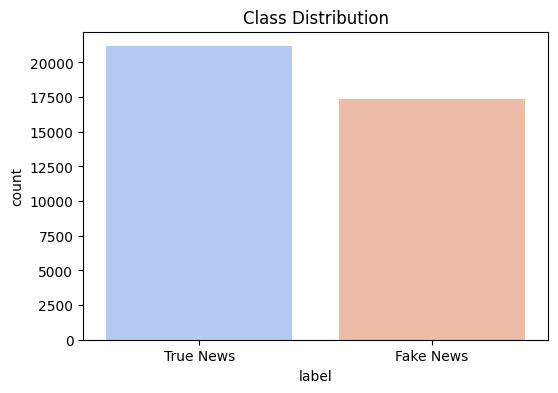

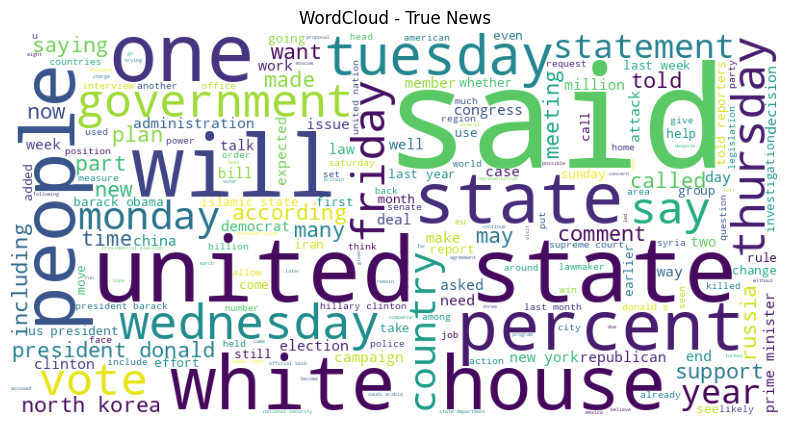

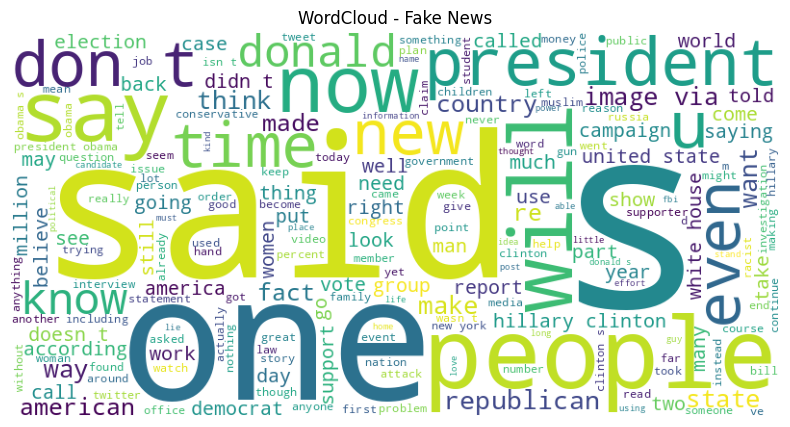

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

# Class balance
plt.figure(figsize=(6,4))
sns.countplot(x="label", data=df, palette="coolwarm")
plt.xticks([0,1], ["True News", "Fake News"])
plt.title("Class Distribution")
plt.show()

# WordClouds
true_text = " ".join(df[df["label"]==0]["clean_text"])
fake_text = " ".join(df[df["label"]==1]["clean_text"])

plt.figure(figsize=(10,5))
plt.imshow(WordCloud(width=800, height=400, background_color="white").generate(true_text))
plt.axis("off")
plt.title("WordCloud - True News")
plt.show()

plt.figure(figsize=(10,5))
plt.imshow(WordCloud(width=800, height=400, background_color="white").generate(fake_text))
plt.axis("off")
plt.title("WordCloud - Fake News")
plt.show()


In [ ]:
print(df.columns)

Index(['title', 'text', 'date', 'label', 'clean_text'], dtype='object')


**EDA Continued**

/tmp/ipython-input-3664103879.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts, y=words, palette="viridis")


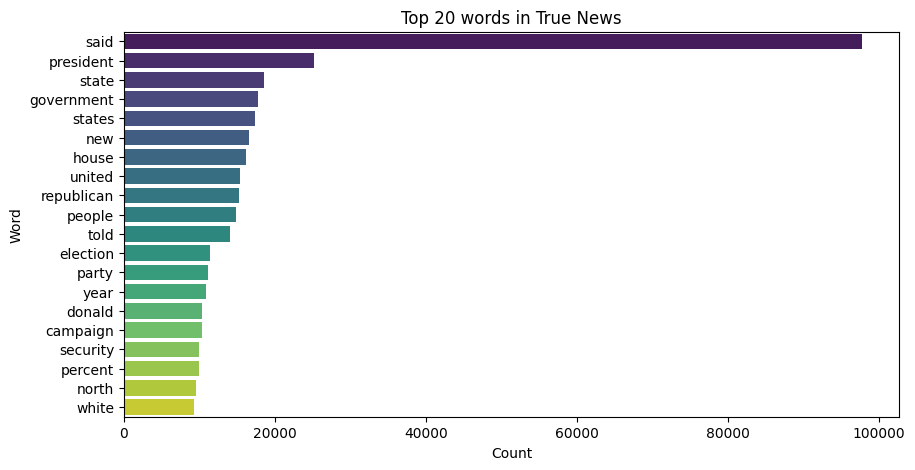

/tmp/ipython-input-3664103879.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts, y=words, palette="viridis")


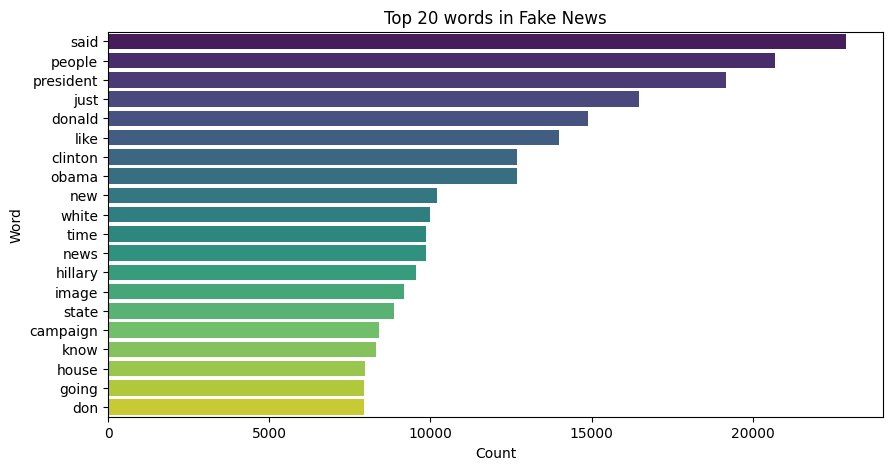

In [ ]:
import matplotlib.pyplot as plt
from collections import Counter
import seaborn as sns
import pandas as pd

# Most common words
from sklearn.feature_extraction.text import CountVectorizer

def plot_top_words(texts, label_name, top_n=20):
    vectorizer = CountVectorizer(stop_words='english', max_features=top_n)
    X = vectorizer.fit_transform(texts)
    freqs = zip(vectorizer.get_feature_names_out(), X.toarray().sum(axis=0))
    freqs = sorted(freqs, key=lambda x: x[1], reverse=True)

    words = [w for w, c in freqs]
    counts = [c for w, c in freqs]

    plt.figure(figsize=(10,5))
    sns.barplot(x=counts, y=words, palette="viridis")
    plt.title(f"Top {top_n} words in {label_name}")
    plt.xlabel("Count")
    plt.ylabel("Word")
    plt.show()

# Top words in True News
plot_top_words(df[df["label"]==0]["clean_text"], "True News", top_n=20)

# Top words in Fake News
plot_top_words(df[df["label"]==1]["clean_text"], "Fake News", top_n=20)





**Deep Cleaning / Tokenization + train/test split**

In [ ]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.model_selection import train_test_split
import numpy as np

# Parameters
MAX_WORDS = 20000
MAX_LEN = 500
TEST_SIZE = 0.2
RANDOM_STATE = 42

# Tokenizer
tokenizer = Tokenizer(num_words=MAX_WORDS, oov_token="<OOV>")
tokenizer.fit_on_texts(df['clean_text'])
sequences = tokenizer.texts_to_sequences(df['clean_text'])
X = pad_sequences(sequences, maxlen=MAX_LEN, padding='post', truncating='post')
y = df['label'].values

# Train/Validation/Test Split
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=RANDOM_STATE, stratify=y_temp)

print("Train shape:", X_train.shape)
print("Validation shape:", X_val.shape)
print("Test shape:", X_test.shape)


Train shape: (30844, 500)
Validation shape: (3856, 500)
Test shape: (3856, 500)


**Training embeddings from scratch**

In [ ]:
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, Bidirectional, SpatialDropout1D, GaussianNoise
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping

# HYPERPARAMETERS

MAX_WORDS = 20000
MAX_LEN = 500
EMBEDDING_DIM = 100
LSTM_UNITS = 16
DENSE_UNITS = 16
DROPOUT_RATE = 0.6
EPOCHS = 10
BATCH_SIZE = 32
RANDOM_STATE = 42

# MODEL
model = Sequential([
    Embedding(input_dim=MAX_WORDS, output_dim=EMBEDDING_DIM, input_length=MAX_LEN),
    SpatialDropout1D(0.4),
    GaussianNoise(0.1),
    Bidirectional(LSTM(LSTM_UNITS, dropout=0.5, recurrent_dropout=0.5)),
    Dense(DENSE_UNITS, activation='relu', kernel_regularizer=l2(0.01)),
    Dropout(DROPOUT_RATE),
    Dense(1, activation='sigmoid')
])

# Compile
model.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

# Summary
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d_2             │ ?                      │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gaussian_noise_2                │ ?                      │             0 │
│ (GaussianNoise)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_2 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

**Training the Model**

In [ ]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=2,
    restore_best_weights=True
)

# TRAINING
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[early_stop],
    verbose=1
)


Epoch 1/10
964/964 ━━━━━━━━━━━━━━━━━━━━ 760s 780ms/step - accuracy: 0.7409 - loss: 0.5612 - val_accuracy: 0.9681 - val_loss: 0.1197
Epoch 2/10
964/964 ━━━━━━━━━━━━━━━━━━━━ 759s 787ms/step - accuracy: 0.9561 - loss: 0.1737 - val_accuracy: 0.9761 - val_loss: 0.0906
Epoch 3/10
964/964 ━━━━━━━━━━━━━━━━━━━━ 759s 788ms/step - accuracy: 0.9679 - loss: 0.1249 - val_accuracy: 0.9774 - val_loss: 0.0830
Epoch 4/10
964/964 ━━━━━━━━━━━━━━━━━━━━ 791s 776ms/step - accuracy: 0.9721 - loss: 0.1087 - val_accuracy: 0.9813 - val_loss: 0.0785
Epoch 5/10
964/964 ━━━━━━━━━━━━━━━━━━━━ 810s 785ms/step - accuracy: 0.9753 - loss: 0.0967 - val_accuracy: 0.9808 - val_loss: 0.0793
Epoch 6/10
964/964 ━━━━━━━━━━━━━━━━━━━━ 750s 778ms/step - accuracy: 0.9775 - loss: 0.0842 - val_accuracy: 0.9816 - val_loss: 0.0740
Epoch 7/10
964/964 ━━━━━━━━━━━━━━━━━━━━ 742s 770ms/step - accuracy: 0.9806 - loss: 0.0726 - val_accuracy: 0.9805 - val_loss: 0.0756
Epoch 8/10
964/964 ━━━━━━━━━━━━━━━━━━━━ 742s 770ms/step - accuracy: 0.9841 -

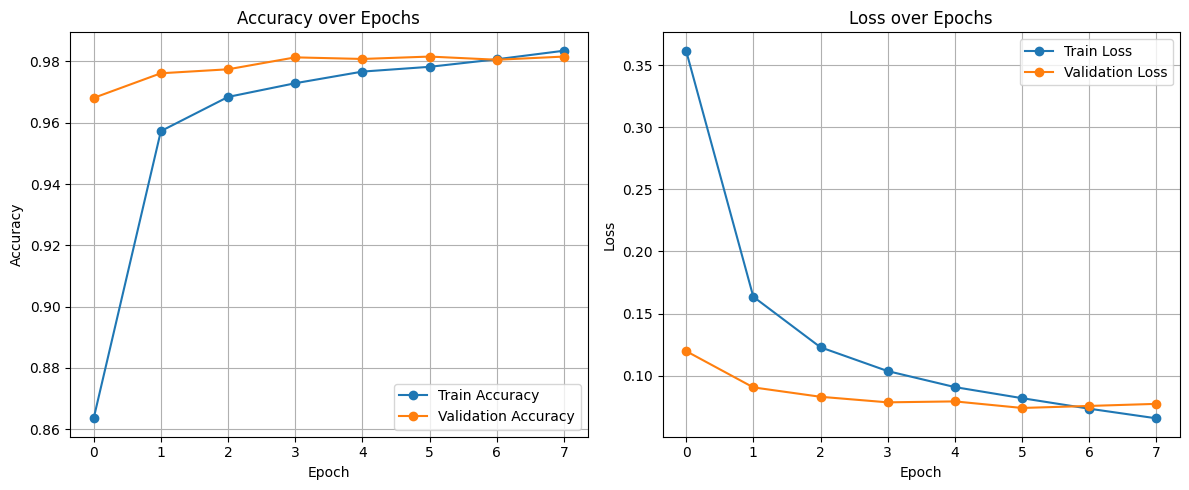

In [ ]:
import matplotlib.pyplot as plt

# Plot training & validation accuracy
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Accuracy', marker='o')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', marker='o')
plt.title('Accuracy over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# Plot training & validation loss
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss', marker='o')
plt.plot(history.history['val_loss'], label='Validation Loss', marker='o')
plt.title('Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


In [ ]:
from sklearn.metrics import classification_report

y_pred = (model.predict(X_test) > 0.5).astype("int32")
print(classification_report(y_test, y_pred, target_names=["True", "Fake"]))

121/121 ━━━━━━━━━━━━━━━━━━━━ 18s 142ms/step
              precision    recall  f1-score   support

        True       0.96      0.99      0.97      2117
        Fake       0.98      0.95      0.96      1739

    accuracy                           0.97      3856
   macro avg       0.97      0.97      0.97      3856
weighted avg       0.97      0.97      0.97      3856



**Evaluate on Test Data**

In [ ]:
test_loss, test_acc = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {test_acc:.4f}")

121/121 ━━━━━━━━━━━━━━━━━━━━ 13s 107ms/step - accuracy: 0.9798 - loss: 0.0807
Test Accuracy: 0.9816


In [ ]:
# --- Pick samples ---
true_samples = true_df['title'].dropna().sample(3, random_state=42).tolist()
fake_samples = fake_df['title'].dropna().sample(3, random_state=42).tolist()
samples = true_samples + fake_samples

# --- Convert to sequences ---
sample_seq = tokenizer.texts_to_sequences(samples)
sample_pad = pad_sequences(sample_seq, maxlen=MAX_LEN, padding='post')

# --- Predict ---
preds = model.predict(sample_pad)

# --- Display ---
for i, sample in enumerate(samples):
    pred_prob = preds[i][0]
    label = "Fake" if pred_prob > 0.5 else "True"
    confidence = pred_prob if pred_prob > 0.5 else 1 - pred_prob
    print(f"\n News: {sample}\n→ Predicted: {label} ({confidence:.2f} confidence)")